<a href="https://colab.research.google.com/github/AHANIK33/Deep-Learning/blob/main/FMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
df = pd.read_csv("/content/fashion-mnist_train.csv")

In [5]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

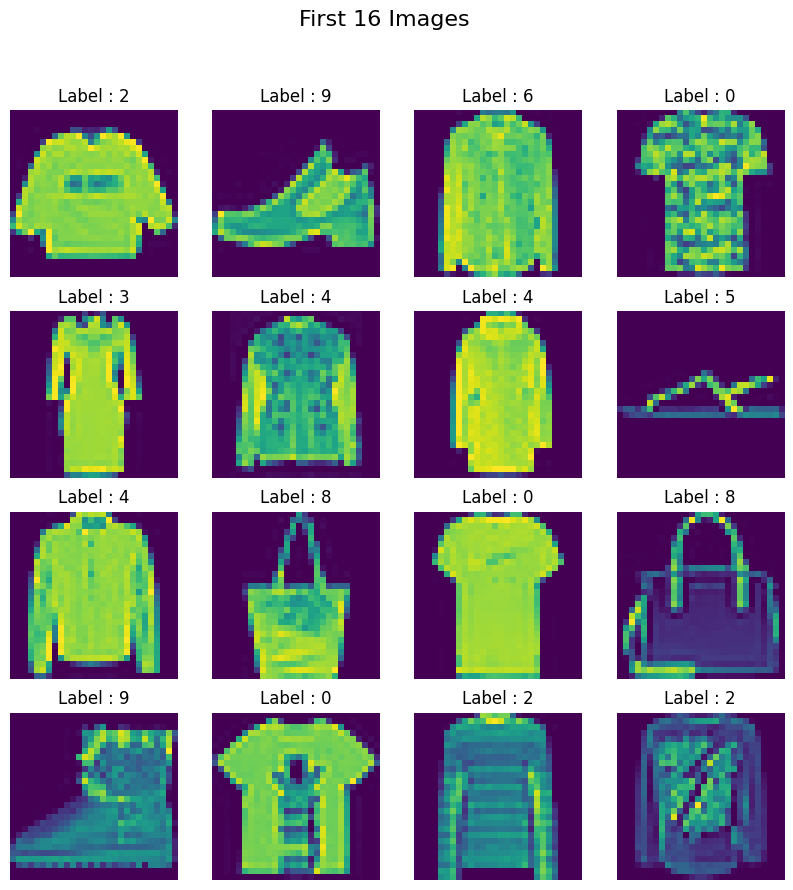

In [7]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images",fontsize=16)

for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label : {df.iloc[i,0]}")

In [8]:
len(df['label'].unique())

10

In [9]:
len(df.columns)

785

In [10]:
len(df.iloc[:,1:])

60000

Train test split

In [11]:
X = df.drop('label',axis=1)
y = df['label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
48572,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38696,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13611,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35213,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31766,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,11,37,6,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,0,0,0,0,0,3,7,0,0,0,...,174,180,196,235,0,0,255,229,166,0
38158,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
15795,0,0,0,0,0,0,0,2,0,0,...,94,74,0,0,0,0,0,0,0,0


Scaling

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Custom Dataset

In [15]:
class CustomDataset(Dataset):

  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index], self.labels[index]

In [16]:
train_dataset = CustomDataset(X_train,y_train.to_numpy())
test_dataset = CustomDataset(X_test,y_test.to_numpy())

In [17]:
len(train_dataset)

48000

In [18]:
train_dataset[0]

(tensor([-0.0096, -0.0224, -0.0283, -0.0412, -0.0564, -0.0707, -0.0987, -0.1556,
         -0.2383, -0.3766, -0.5692, -0.6928, -0.7579, -0.7485, -0.7485, -0.7742,
         -0.7566, -0.6463, -0.5019, -0.3191, -0.2026, -0.1405, -0.1114, -0.0929,
         -0.0674, -0.0492, -0.0324, -0.0150, -0.0123, -0.0172, -0.0334, -0.0541,
         -0.0789, -0.1318, -0.2431, -0.3631, -0.4879, -0.6428, -0.8317, -1.0016,
         -1.0906, -1.0813, -1.0659, -1.1068, -1.0879, -0.9373, -0.7792, -0.5953,
         -0.4407, -0.3157, -0.2082, -0.1502, -0.1187, -0.0898, -0.0568, -0.0285,
         -0.0155, -0.0250, -0.0441, -0.0743, -0.1297, -0.2683, -0.4031, -0.5032,
         -0.6317, -0.8203, -0.9921, -1.0695, -1.0983, -1.0963, -1.0900, -1.1196,
         -1.1156, -1.0776, -0.9747, -0.7784, -0.5943, -0.4834, -0.3713, -0.2413,
         -0.1724, -0.1306, -0.0889, -0.0520, -0.0261, -0.0399, -0.0659, -0.1040,
         -0.2149, -0.3707, -0.5072, -0.6404, -0.7649, -0.9319, -1.0498, -1.0942,
         -1.1022, -1.1007, -

In [19]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

Define NN Class

In [20]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self,X):
    return self.model(X)

Instantiate Model

In [21]:
epochs = 25
learning_rate = 0.1

In [22]:
model = MyNN(X_train.shape[1])

In [23]:
model=model.to(device)

In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
model.parameters

<bound method Module.parameters of MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)>

In [26]:
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [27]:
len(train_loader)

1500

Training loop

In [28]:
for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features = batch_features.to(device)
    batch_labels = batch_labels.to(device)

    output = model(batch_features)

    loss = criterion(output,batch_labels)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

avg_loss = total_epoch_loss/len(train_loader)
print(avg_loss)

0.10140799267070058


Evaluation

In [29]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        predicted = torch.argmax(outputs, dim=1)

        all_predictions.extend(predicted.cpu())
        all_labels.extend(batch_labels.cpu())

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Accuracy = {accuracy*100}")

Accuracy = 88.14999999999999
